# 03b — End-to-end pipeline (live, your own graph)

Identical structure to `03a`, but the user controls the graph and the
Dirac backend (cloud or direct). The orchestration captures Dirac
responses to disk so the run can be replayed offline later.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import _demo_utils as U
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import time

from quantum_colgen.column_generation import column_generation
from quantum_colgen.pricing.classical_lp import ClassicalLPPricingOracle
from quantum_colgen.direct_ilp import solve_coloring_ilp_highs
from quantum_colgen.graphs import erdos_renyi


In [2]:
# ── Configuration ───────────────────────────────────────────────────
BACKEND = "replay"        # "replay" | "cloud" | "direct"

# Direct hardware endpoint (only used when BACKEND == "direct").
# Skill-documented default 172.18.41.79 is offline; 172.18.41.228 is current.
DIRECT_IP = "172.18.41.228"
DIRECT_PORT = 50051
SAVE_RUN = True

NODES, EDGE_PROB, SEED = 20, 0.5, 42
DIRAC_TIME_BUDGET = 600   # seconds for the Quantum-CG run
HEXALY_TIME_BUDGET = 60   # seconds for Hexaly
HIGHS_TIME_BUDGET = 60    # seconds for HiGHS
QBP_TIME_BUDGET = 60      # seconds for Classical B&P
# ────────────────────────────────────────────────────────────────────

U.load_dotenv_if_present()


False

Instance: er_n20_p70_s0  n=20  m=131


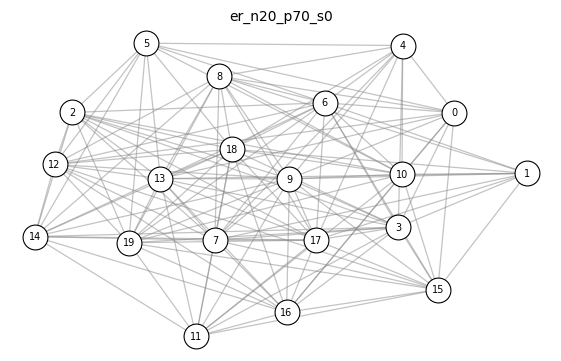

In [3]:
if BACKEND == "replay":
    psp = U.load_psp(1)
    G = U.psp_to_graph(psp)
    layout = U.psp_to_layout(psp)
    instance_label = psp["instance_id"]
else:
    G = erdos_renyi(NODES, EDGE_PROB, seed=SEED)
    layout = nx.kamada_kawai_layout(G)
    layout = {int(v): (float(p[0]), float(p[1])) for v, p in layout.items()}
    instance_label = f"er_{NODES}_{EDGE_PROB}_s{SEED}"

print(f"Instance: {instance_label}  n={G.number_of_nodes()}  m={G.number_of_edges()}")
fig, ax = plt.subplots(figsize=(5.5, 3.5), constrained_layout=True)
U.draw_graph(ax, G, layout, node_color="white", title=instance_label)
plt.show()


In [4]:
run_dir = None
if BACKEND in ("cloud", "direct") and SAVE_RUN:
    run_dir = U.new_run_dir(label=f"appdemo_{BACKEND}")
    U.save_run_metadata(run_dir, G, {
        "backend": BACKEND, "instance": instance_label,
        "n": G.number_of_nodes(), "m": G.number_of_edges(),
    })
    print(f"Saving Dirac responses to {run_dir}")


## Run all six solvers

In [5]:
results = {}

# (a) Greedy
t0 = time.monotonic()
greedy_color = nx.coloring.greedy_color(G, strategy="DSATUR")
wall = time.monotonic() - t0
gclasses = {}
for v, c in greedy_color.items():
    gclasses.setdefault(c, set()).add(v)
results["Greedy (DSATUR)"] = {
    "chi": len(gclasses), "runtime_s": wall,
    "coloring": list(gclasses.values()),
}
print(f"Greedy (DSATUR): χ={len(gclasses)}  wall={wall*1000:.1f}ms")


Greedy (DSATUR): χ=8  wall=0.3ms


In [6]:
# (b) HiGHS
t0 = time.monotonic()
chi_h, coloring_h, _, info_h = solve_coloring_ilp_highs(G, time_limit=HIGHS_TIME_BUDGET)
wall = time.monotonic() - t0
results["HiGHS exact ILP"] = {
    "chi": chi_h, "runtime_s": wall, "coloring": coloring_h or [],
    "notes": "optimal" if info_h.get("optimal") else "best-found",
}
print(f"HiGHS: χ={chi_h}  wall={wall:.2f}s")


HiGHS: χ=8  wall=0.07s


In [7]:
# (c) Hexaly
try:
    from quantum_colgen.direct_ilp import solve_coloring_ilp_hexaly
    t0 = time.monotonic()
    chi_x, coloring_x, _, info_x = solve_coloring_ilp_hexaly(
        G, time_limit=HEXALY_TIME_BUDGET)
    wall = time.monotonic() - t0
    results["Hexaly exact ILP"] = {
        "chi": chi_x, "runtime_s": wall, "coloring": coloring_x or [],
        "notes": "optimal" if info_x.get("optimal") else "best-found",
    }
    print(f"Hexaly: χ={chi_x}  wall={wall:.2f}s")
except Exception as e:
    print(f"Hexaly skipped: {type(e).__name__}: {e}")


Hexaly: χ=None  wall=0.02s


In [8]:
# (d) Classical CG
classical_oracle = ClassicalLPPricingOracle()
t0 = time.monotonic()
chi_c, coloring_c, stats_c = column_generation(
    G, classical_oracle, max_iterations=500, verbose=False)
wall = time.monotonic() - t0
results["Classical CG"] = {
    "chi": chi_c, "runtime_s": wall,
    "iterations": stats_c.get("iterations"),
    "columns_per_call": classical_oracle.timer.summary().get('avg_columns_per_call'),
    "api_calls": classical_oracle.timer.summary().get('num_api_calls'),
    "coloring": [set(c) for c in coloring_c],
}
print(f"Classical CG: χ={chi_c}  wall={wall:.2f}s")


Classical CG: χ=8  wall=0.02s


In [9]:
# (e) Quantum CG (live or replay)
inner = U.make_dirac_oracle(
    BACKEND, method="gibbons",
    num_samples=100, multi_prune=True, randomized_rounding=True,
    direct_ip_address=DIRECT_IP, direct_port=DIRECT_PORT,
)
qc_oracle = inner
if run_dir is not None:
    qc_oracle = U.CapturingPricingOracle(qc_oracle, run_dir=run_dir)

t0 = time.monotonic()
chi_q, coloring_q, stats_q = column_generation(
    G, qc_oracle, max_iterations=500, verbose=False,
    time_limit=DIRAC_TIME_BUDGET,
)
wall = time.monotonic() - t0
results[f"Quantum CG (Dirac, {BACKEND})"] = {
    "chi": chi_q, "runtime_s": wall,
    "iterations": stats_q.get("iterations"),
    "columns_per_call": inner.timer.summary().get('avg_columns_per_call'),
    "api_calls": inner.timer.summary().get('num_api_calls'),
    "coloring": [set(c) for c in coloring_q],
    "notes": ("device replayed offline" if BACKEND == "replay"
              else "live Dirac"),
}
print(f"Quantum CG ({BACKEND}): χ={chi_q}  wall={wall:.2f}s  "
      f"iters={stats_q.get('iterations')}")


Quantum CG (replay): χ=8  wall=0.23s  iters=5


In [10]:
# (f) Classical B&P (single-child IS-fixing)
import subprocess, json, tempfile
QBP_DIR = U.REPO_ROOT / "quantum-branch-price"
qbp_run = QBP_DIR / "scripts" / "run_bp.py"

if BACKEND == "replay":
    qbp_graph_arg = "er_20_0.7_s0"
else:
    qbp_graph_arg = f"er_{NODES}_{EDGE_PROB}_s{SEED}"

try:
    if not qbp_run.exists():
        raise RuntimeError(f"qbp run_bp.py not found at {qbp_run}")
    with tempfile.TemporaryDirectory() as td:
        out = Path(td) / "result.json"
        proc = subprocess.run(
            ["uv", "run", "python", str(qbp_run),
             "--graph", qbp_graph_arg, "--branching", "is_fixing",
             "--oracle", "classical-lp",
             "--time-limit", str(QBP_TIME_BUDGET),
             "--ilp-time-limit", "30", "--json", str(out)],
            cwd=str(QBP_DIR), capture_output=True, text=True,
            timeout=QBP_TIME_BUDGET + 60,
        )
        t0 = time.monotonic()
        if proc.returncode != 0:
            raise RuntimeError(f"qbp returncode={proc.returncode}: "
                               f"{proc.stderr[-300:]}")
        if not out.exists():
            raise RuntimeError("qbp wrote no JSON")
        rec = json.loads(out.read_text())
        if isinstance(rec, list) and rec:
            rec = rec[0]
        if not isinstance(rec, dict):
            raise RuntimeError(f"unexpected qbp output schema: {type(rec).__name__}")
        wall = time.monotonic() - t0   # near-zero; subprocess time is wallclock above
        chi_bp = rec.get("chi") or next((m.get("chi") for m in rec.get("methods", {}).values()), None)
        results["Classical B&P (IS-fixing)"] = {
            "chi": chi_bp, "runtime_s": next((m.get("wall_seconds", 0.0) for m in rec.get("methods", {}).values()), 0.0),
            "iterations": next((m.get("nodes_explored") for m in rec.get("methods", {}).values()), None),
            "coloring": [],
            "notes": f"{next((m.get('nodes_explored') for m in rec.get('methods', {}).values()), None)} B&B nodes",
        }
        print(f"Classical B&P: χ={chi_bp}  "
              f"wall={results['Classical B&P (IS-fixing)']['runtime_s']:.2f}s  "
              f"nodes={next((m.get('nodes_explored') for m in rec.get('methods', {}).values()), None)}")
except Exception as e:
    print(f"Classical B&P skipped: {type(e).__name__}: {e}")


Classical B&P: χ=8  wall=0.01s  nodes=1


## Comparison

In [11]:
df = pd.DataFrame([
    {"solver": k, "χ": v["chi"], "runtime_s": round(v["runtime_s"], 2),
     "iterations": v.get("iterations"),
     "cols/call": (round(v["columns_per_call"], 2)
                   if v.get("columns_per_call") else None),
     "api_calls": v.get("api_calls"),
     "notes": v.get("notes", "")}
    for k, v in results.items()
])
df


,solver,χ,runtime_s,iterations,cols/call,api_calls,notes
0,Greedy (DSATUR),8.0,0.00,NaN,NaN,NaN,
1,HiGHS exact ILP,8.0,0.07,NaN,NaN,NaN,best-found
2,Hexaly exact ILP,NaN,0.02,NaN,NaN,NaN,best-found
3,Classical CG,8.0,0.02,3.0,7.50,4.0,
4,"Quantum CG (Dirac, replay)",8.0,0.23,5.0,4.67,6.0,device replayed offline
5,Classical B&P (IS-fixing),8.0,0.01,1.0,NaN,NaN,1 B&B nodes


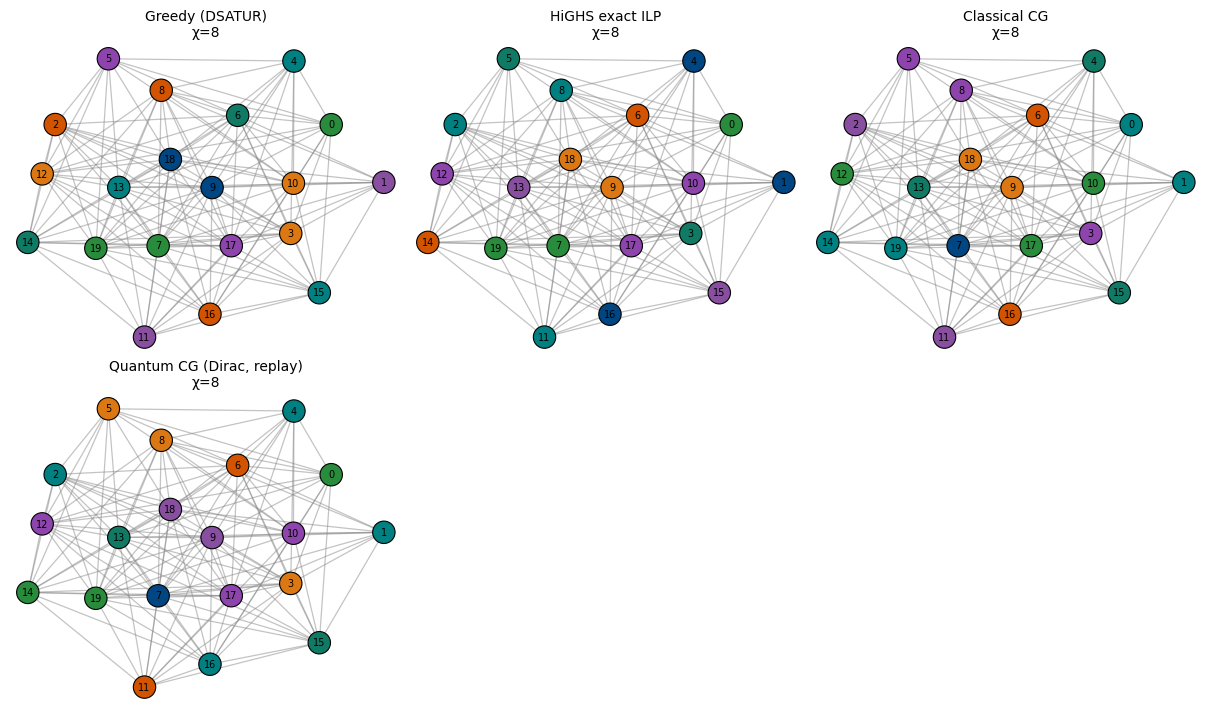

In [12]:
# Coloring small-multiples
solvers_with_coloring = [(k, v) for k, v in results.items()
                          if v.get("coloring")]
ncols = 3
nrows = (len(solvers_with_coloring) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 3.5 * nrows),
                         constrained_layout=True)
axes = np.atleast_2d(axes).reshape(nrows, ncols)
for k, (name, v) in enumerate(solvers_with_coloring):
    r, c = divmod(k, ncols)
    U.draw_coloring(G, v["coloring"], layout, ax=axes[r, c],
                    title=f"{name}\nχ={v['chi']}")
for k in range(len(solvers_with_coloring), nrows * ncols):
    r, c = divmod(k, ncols)
    axes[r, c].set_visible(False)
plt.show()


## Persisting and re-replaying the run

In [13]:
if run_dir is not None and run_dir.exists():
    # Save the comparison table next to the raw samples
    (run_dir / "comparison.json").write_text(df.to_json(orient="records", indent=2))
    print(f"Run artifacts: {run_dir}")
    print(f"  comparison.json — solver stats")
    print(f"  graph.json      — instance metadata")
    print(f"  raw_samples/    — {len(list((run_dir / 'raw_samples').glob('call_*.pkl')))} Dirac calls")
    print()
    print(f"To replay later, in any notebook:")
    print(f"    oracle = U.replay_oracle_from_run(\"{run_dir}\")")
    print(f"    column_generation(G, oracle, ...)")
else:
    print("No run captured (replay mode or SAVE_RUN=False).")


No run captured (replay mode or SAVE_RUN=False).
